# Week 6 – K-Nearest Neighbor (KNN)
## Exercise Q-1: Classification of Fruits

**Q-1.A** — Manual KNN implementation (no scikit-learn)
**Q-1.B** — KNN implementation using scikit-learn

Dataset:

| Fruit ID | Weight (g) | Sweetness | Label |
|---|---|---|---|
| 1 | 180 | 7 | Apple |
| 2 | 200 | 6 | Apple |
| 3 | 150 | 4 | Orange |
| 4 | 170 | 5 | Orange |
| 5 | 160 | 6 | Apple |
| 6 | 140 | 3 | Orange |

New fruit to classify: **weight = 165 g, sweetness = 5.5**


---
## Q-1.A : Manual KNN Implementation (without scikit-learn)

### 1. Imports and Dataset

In [1]:
import math
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

# Dataset: (Fruit ID, Weight, Sweetness, Label)
dataset = [
    (1, 180, 7, "Apple"),
    (2, 200, 6, "Apple"),
    (3, 150, 4, "Orange"),
    (4, 170, 5, "Orange"),
    (5, 160, 6, "Apple"),
    (6, 140, 3, "Orange"),
]

new_point = (165, 5.5)  # (weight, sweetness)


### 2. Distance Functions (Euclidean, Manhattan, Minkowski)

In [2]:
def euclidean_distance(p1, p2):
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(p1, p2)))


def manhattan_distance(p1, p2):
    return sum(abs(a - b) for a, b in zip(p1, p2))


def minkowski_distance(p1, p2, p=3):
    return sum(abs(a - b) ** p for a, b in zip(p1, p2)) ** (1 / p)


### 3. Task 2 — Compute & Compare Distances for Every Fruit

In [3]:
print("=" * 90)
print(f"New fruit -> Weight = {new_point[0]} g, Sweetness = {new_point[1]}")
print("=" * 90)
header = f"{'ID':<4}{'Weight':<10}{'Sweetness':<11}{'Label':<9}{'Euclidean':<12}{'Manhattan':<12}{'Minkowski(p=3)':<15}"
print(header)
print("-" * len(header))

distance_rows = []
for fid, w, s, label in dataset:
    p1 = (w, s)
    d_euc = euclidean_distance(p1, new_point)
    d_man = manhattan_distance(p1, new_point)
    d_min = minkowski_distance(p1, new_point, p=3)
    distance_rows.append((fid, w, s, label, d_euc, d_man, d_min))
    print(f"{fid:<4}{w:<10}{s:<11}{label:<9}{d_euc:<12.4f}{d_man:<12.4f}{d_min:<15.4f}")


New fruit -> Weight = 165 g, Sweetness = 5.5
ID  Weight    Sweetness  Label    Euclidean   Manhattan   Minkowski(p=3) 
-------------------------------------------------------------------------
1   180       7          Apple    15.0748     16.5000     15.0050        
2   200       6          Apple    35.0036     35.5000     35.0000        
3   150       4          Orange   15.0748     16.5000     15.0050        
4   170       5          Orange   5.0249      5.5000      5.0017         
5   160       6          Apple    5.0249      5.5000      5.0017         
6   140       3          Orange   25.1247     27.5000     25.0083        


### 4. KNN Classifier Function (Steps: sort → top-k → majority vote)

In [4]:
def knn_classify(dataset, new_point, k, distance_fn=euclidean_distance):
    distances = []
    for fid, w, s, label in dataset:
        d = distance_fn((w, s), new_point)
        distances.append((d, label, fid))
    distances.sort(key=lambda x: x[0])          # step b: sort ascending
    k_nearest = distances[:k]                    # step c: top-k rows
    labels = [item[1] for item in k_nearest]
    vote = Counter(labels).most_common(1)[0][0]  # step d: majority vote
    return vote, k_nearest


### 5. Task 1 & 3 — Classify with k = 3 (Euclidean distance)

In [5]:
k = 3
prediction, neighbors = knn_classify(dataset, new_point, k)

print("=" * 90)
print(f"K = {k} Nearest Neighbors (sorted by Euclidean distance):")
for d, label, fid in neighbors:
    print(f"  Fruit ID {fid}: distance = {d:.4f}, label = {label}")
print(f"\nMajority vote among {k} nearest neighbors -> Predicted label = \'{prediction}\'")
print("=" * 90)


K = 3 Nearest Neighbors (sorted by Euclidean distance):
  Fruit ID 4: distance = 5.0249, label = Orange
  Fruit ID 5: distance = 5.0249, label = Apple
  Fruit ID 1: distance = 15.0748, label = Apple

Majority vote among 3 nearest neighbors -> Predicted label = 'Apple'


### 6. Task 4 — Effect of Different k Values (k=1, 3, 5)

In [6]:
print("Effect of different k values on classification:")
for k_val in [1, 3, 5]:
    pred, neigh = knn_classify(dataset, new_point, k_val)
    used = [f"ID{fid}({label},{d:.2f})" for d, label, fid in neigh]
    print(f"  k={k_val}: neighbors used = {used} -> Predicted = {pred}")


Effect of different k values on classification:
  k=1: neighbors used = ['ID4(Orange,5.02)'] -> Predicted = Orange
  k=3: neighbors used = ['ID4(Orange,5.02)', 'ID5(Apple,5.02)', 'ID1(Apple,15.07)'] -> Predicted = Apple
  k=5: neighbors used = ['ID4(Orange,5.02)', 'ID5(Apple,5.02)', 'ID1(Apple,15.07)', 'ID3(Orange,15.07)', 'ID6(Orange,25.12)'] -> Predicted = Orange


### 7. Task 6 — Plot Samples, New Point, and Decision Boundary (k=3)

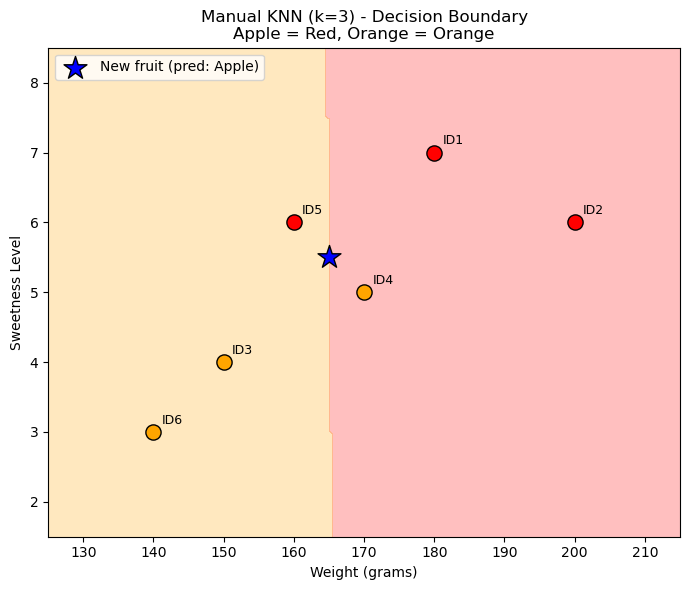

In [7]:
weights = np.array([row[1] for row in dataset])
sweetness = np.array([row[2] for row in dataset])
labels = np.array([row[3] for row in dataset])

fig, ax = plt.subplots(figsize=(7, 6))

# Build a mesh grid over the feature space
w_min, w_max = weights.min() - 15, weights.max() + 15
s_min, s_max = sweetness.min() - 1.5, sweetness.max() + 1.5
ww, ss = np.meshgrid(np.linspace(w_min, w_max, 200), np.linspace(s_min, s_max, 200))

grid_points = np.c_[ww.ravel(), ss.ravel()]
grid_preds = []
for gp in grid_points:
    pred, _ = knn_classify(dataset, tuple(gp), k=3)
    grid_preds.append(0 if pred == "Apple" else 1)
grid_preds = np.array(grid_preds).reshape(ww.shape)

ax.contourf(ww, ss, grid_preds, alpha=0.25, levels=[-0.5, 0.5, 1.5],
            colors=["red", "orange"])

# Plot the training samples
for fid, w, s, label in dataset:
    color = "red" if label == "Apple" else "orange"
    ax.scatter(w, s, c=color, edgecolors="black", s=120, zorder=3)
    ax.annotate(f"ID{fid}", (w, s), textcoords="offset points", xytext=(6, 6), fontsize=9)

# Plot the new point
ax.scatter(new_point[0], new_point[1], c="blue", marker="*", s=300,
           edgecolors="black", zorder=4, label=f"New fruit (pred: {prediction})")

ax.set_xlabel("Weight (grams)")
ax.set_ylabel("Sweetness Level")
ax.set_title(f"Manual KNN (k=3) - Decision Boundary\nApple = Red, Orange = Orange")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


---
## Q-1.B : KNN Implementation using scikit-learn

### 1. Imports and Dataset

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial import distance

X = np.array([
    [180, 7],
    [200, 6],
    [150, 4],
    [170, 5],
    [160, 6],
    [140, 3],
])
y = np.array(["Apple", "Apple", "Orange", "Orange", "Apple", "Orange"])

new_fruit = np.array([[165, 5.5]])


### 2. Distance Comparison (Euclidean, Manhattan, Minkowski p=3)

In [9]:
print("=" * 80)
print("Distance comparison (scikit-learn / scipy) - new fruit vs each sample")
print("=" * 80)
print(f"{'Sample':<10}{'Label':<9}{'Euclidean':<12}{'Manhattan':<12}{'Minkowski(p=3)':<15}")
for i in range(len(X)):
    d_euc = distance.euclidean(X[i], new_fruit[0])
    d_man = distance.cityblock(X[i], new_fruit[0])
    d_min = distance.minkowski(X[i], new_fruit[0], p=3)
    print(f"ID{i+1:<8}{y[i]:<9}{d_euc:<12.4f}{d_man:<12.4f}{d_min:<15.4f}")


Distance comparison (scikit-learn / scipy) - new fruit vs each sample
Sample    Label    Euclidean   Manhattan   Minkowski(p=3) 
ID1       Apple    15.0748     16.5000     15.0050        
ID2       Apple    35.0036     35.5000     35.0000        
ID3       Orange   15.0748     16.5000     15.0050        
ID4       Orange   5.0249      5.5000      5.0017         
ID5       Apple    5.0249      5.5000      5.0017         
ID6       Orange   25.1247     27.5000     25.0083        


### 3. Effect of k on Prediction (k=1, 3, 5)

In [10]:
print("=" * 80)
print("Effect of k on prediction (scikit-learn KNeighborsClassifier, Euclidean)")
print("=" * 80)
for k in [1, 3, 5]:
    clf = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    clf.fit(X, y)
    pred = clf.predict(new_fruit)[0]
    print(f"  k={k} -> Predicted label = {pred}")

# Final model used for plotting: k = 3, Euclidean
k = 3
clf = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
clf.fit(X, y)
final_pred = clf.predict(new_fruit)[0]
print(f"\nFinal chosen model: k={k}, metric=euclidean -> Predicted label for new fruit = {final_pred}")


Effect of k on prediction (scikit-learn KNeighborsClassifier, Euclidean)
  k=1 -> Predicted label = Orange
  k=3 -> Predicted label = Orange
  k=5 -> Predicted label = Orange

Final chosen model: k=3, metric=euclidean -> Predicted label for new fruit = Orange


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

### 4. Plot Samples and Decision Boundary

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


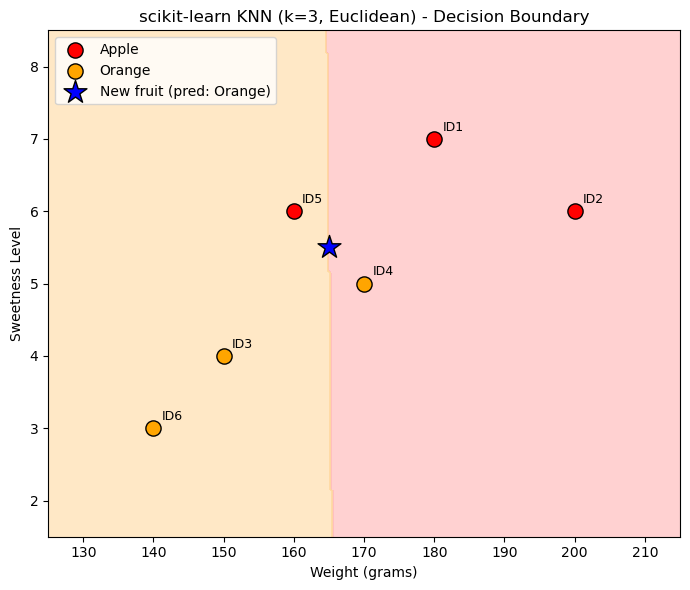

In [11]:
cmap_light = ListedColormap(["#FFB3B3", "#FFD9A0"])  # light red / light orange
label_to_int = {"Apple": 0, "Orange": 1}
y_int = np.array([label_to_int[label] for label in y])

w_min, w_max = X[:, 0].min() - 15, X[:, 0].max() + 15
s_min, s_max = X[:, 1].min() - 1.5, X[:, 1].max() + 1.5
ww, ss = np.meshgrid(np.linspace(w_min, w_max, 300), np.linspace(s_min, s_max, 300))

grid = np.c_[ww.ravel(), ss.ravel()]
Z = clf.predict(grid)
Z_int = np.array([label_to_int[val] for val in Z]).reshape(ww.shape)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(ww, ss, Z_int, cmap=cmap_light, alpha=0.6)

for label, color in [("Apple", "red"), ("Orange", "orange")]:
    mask = y == label
    ax.scatter(X[mask, 0], X[mask, 1], c=color, edgecolors="black", s=120,
               label=label, zorder=3)

for i in range(len(X)):
    ax.annotate(f"ID{i+1}", (X[i, 0], X[i, 1]), textcoords="offset points",
                xytext=(6, 6), fontsize=9)

ax.scatter(new_fruit[0, 0], new_fruit[0, 1], c="blue", marker="*", s=300,
           edgecolors="black", zorder=4, label=f"New fruit (pred: {final_pred})")

ax.set_xlabel("Weight (grams)")
ax.set_ylabel("Sweetness Level")
ax.set_title(f"scikit-learn KNN (k={k}, Euclidean) - Decision Boundary")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


---
### Note on the k=3 discrepancy between Q1.A and Q1.B

The manual implementation predicts **Apple** at k=3, while scikit-learn predicts **Orange**.
This is because ID1 and ID3 are *exactly tied* in distance (15.0748), just like ID4/ID5 are tied
(5.0249). The manual code's stable sort keeps ID1 (Apple) ahead of ID3 (Orange) since it appears
earlier in the list, giving 2 Apple vs 1 Orange. scikit-learn's internal neighbor search picks
ID3 (Orange) instead, giving 2 Orange vs 1 Apple. This is a genuine KNN caveat — exact distance
ties are broken differently by different implementations, and the new point sits almost exactly
on the decision boundary here.